In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import networkx as nx

from matplotlib.patches import Patch
from IPython.display import Markdown, display

from config import PROCESSED_DATA_DIR
from src.graph.ring_case_analysis import SAMLDRingCaseAnalyzer

**Ring case investigation**

Notebook 07 ranked exactly **780,013 non-seed candidates** with pooled seed sets. At a review budget of 1,000 **accounts**, forward unweighted Personalized PageRank (PPR) recovered **210 of 577 withheld targets** across **64 of 129 approximate rings**; the equal-weight forward/reverse score blend (bidirectional unweighted blend) recovered **134 targets** across **65 rings**

This notebook explains those aggregate outcomes through 4 deliberately contrasting rings. Labels are joined only after candidates are ranked, and the path checks below are retrospective diagnostics. The analysis therefore explains the saved validation ranking; it does not retrain PPR or provide an independent test-set estimate

In [2]:
### open the pooled PPR ring experiment and score table produced by notebook 07
# ring experiment directiory
ring_experiment_dir = PROCESSED_DATA_DIR / 'graph' / 'ring_expansion_validation'

# score table directory 
score_table_path = ring_experiment_dir / 'personalized_pagerank_scores.parquet'

# create case analyzer instance
case_analyzer = SAMLDRingCaseAnalyzer(
    experiment_dir = ring_experiment_dir,
    k = 1_000,
    score_path = score_table_path
)

# ring comparison table
ring_comparison = case_analyzer.build_ring_comparison()

ring_comparison_summary = (
    ring_comparison
    .select(
        [
            # ring count
            pl.len()
            .alias(
                'ring_count'
            ),
            # target_count
            pl.col('target_count')
            .sum()
            .alias(
                'target_count'
            ),
            # forward targets at k
            pl.col('forward_hits')
            .sum()
            .alias(
                'forward_targets_at_k'
            ),
            # reverse targets at k
            pl.col('reverse_hits')
            .sum()
            .alias(
                'reverse_targets_at_k'
            ),
            # bidirectional targets at k
            pl.col('bidirectional_hits')
            .sum()
            .alias(
                'bidirectional_targets_at_k'
            ),
            # forward rings hit
            (
                pl.col('forward_hits') > 0
            )
            .sum()
            .alias(
                'forward_rings_hit'
            ),
            # reverse rings hit
            (
                pl.col('reverse_hits') > 0
            )
            .sum()
            .alias(
                'reverse_rings_hit'
            ),
            # bidirectional rings hit
            (
                pl.col('bidirectional_hits') > 0
            )
            .sum()
            .alias(
                'bidirectional_rings_hit'
            )
        ]
    )
    .with_columns(
        [
            # forward target coverage
            (
                pl.col('forward_targets_at_k') / pl.col('target_count')
            )
            .alias(
                'forward_target_coverage'
            ),
            # reverse target coverage
            (
                pl.col('reverse_targets_at_k') / pl.col('target_count')
            )
            .alias(
                'reverse_target_coverage'
            ),
            # bidirectional target coverage
            (
                pl.col('bidirectional_targets_at_k') / pl.col('target_count')
            )
            .alias(
                'bidirectional_target_coverage'
            ),
            # forward ring coverage
            (
                pl.col('forward_rings_hit') / pl.col('ring_count')
            )
            .alias(
                'forward_ring_coverage'
            ),
            # reverse ring coverage
            (
                pl.col('reverse_rings_hit') / pl.col('ring_count')
            )
            .alias(
                'reverse_ring_coverage'
            ),
            # forward ring coverage
            (
                pl.col('bidirectional_rings_hit') / pl.col('ring_count')
            )
            .alias(
                'bidirectional_ring_coverage'
            )
        ]
    )
)

with pl.Config(tbl_cols = -1):
    display(ring_comparison_summary)

print(
    f'Analysis budget: top {case_analyzer.k:,} candidates'
)

ring_count,target_count,forward_targets_at_k,reverse_targets_at_k,bidirectional_targets_at_k,forward_rings_hit,reverse_rings_hit,bidirectional_rings_hit,forward_target_coverage,reverse_target_coverage,bidirectional_target_coverage,forward_ring_coverage,reverse_ring_coverage,bidirectional_ring_coverage
u32,u64,u32,u32,u32,u32,u32,u32,f64,f64,f64,f64,f64,f64
129,577,210,104,134,64,60,65,0.363951,0.180243,0.232236,0.496124,0.465116,0.503876


Analysis budget: top 1,000 candidates


**Overall result interpretation**

The reproduced totals agree with notebook 07, so the persisted score table and the case-analysis ranking logic are aligned

- **Forward PPR**: **210/577 targets** (**36.4%**) and **64/129 rings** (**49.6%**) are hit
- **Reverse PPR**: **104/577 targets** (**18.0%**) and **60/129 rings** (**46.5%**) are hit
- **Forward/reverse blend**: **134/577 targets** (**23.2%**) and **65/129 rings** (**50.4%**) are hit


The blend reaches **one additional ring** relative to forward PPR, but it returns **76 fewer true targets** at the same review budget. In this experiment, forward PPR therefore provides greater depth within recoverable rings, whereas the blend provides a very small increase in ring breadth. A ring is counted as *hit* when at least one of its withheld targets appears in the global, not ring-specific, top 1,000 

In [3]:
### compare forward and blended rankings ring-by-ring
with pl.Config(
    tbl_cols = -1,
    tbl_rows = -1,
    fmt_str_lengths = 40
):
    display(
        ring_comparison
        .sort(
            [
                'blend_gain',
                'forward_hits',
                'ring_id'
            ],
            descending = [
                True,
                True,
                False
            ]
        )
        .head(10)
    )

# status summary
status_summary = (
    ring_comparison
    .group_by('forward_status')
    .agg(
        [
            # ring count by forward status
            pl.len()
            .alias(
                'ring_count'
            ),
            # target count by forward status
            pl.col('target_count')
            .sum()
            .alias(
                'target_count'
            )
        ]
    )
    .sort(
        'forward_status'
    )
)

display(status_summary)

ring_id,ring_size,seed_count,target_count,forward_hits,reverse_hits,bidirectional_hits,forward_first_rank,reverse_first_rank,bidirectional_first_rank,blend_gain,forward_ring_recall,bidirectional_ring_recall,forward_status
u64,u64,u64,u64,u32,u32,u32,u32,u32,u32,i64,f64,f64,str
67,12,3,9,1,3,4,12,47,60,3,0.111111,0.444444,"""partial"""
52,4,1,3,0,3,3,319326,79,167,3,0.0,1.0,"""missed"""
60,5,2,3,0,3,3,94602,542,808,3,0.0,1.0,"""missed"""
101,8,2,6,0,4,3,199872,599,916,3,0.0,0.5,"""missed"""
3,11,3,8,6,2,8,119,523,457,2,0.75,1.0,"""partial"""
15,10,3,7,1,4,3,794,138,275,2,0.142857,0.428571,"""partial"""
77,5,2,3,1,2,3,243,518,760,2,0.333333,1.0,"""partial"""
21,13,4,9,0,6,2,217148,548,818,2,0.0,0.222222,"""missed"""
36,3,1,2,0,2,2,541975,71,120,2,0.0,1.0,"""missed"""


forward_status,ring_count,target_count
str,u32,u64
"""complete""",28,141
"""missed""",65,277
"""partial""",36,159


**Ring-level comparison**

`forward_hits`, `reverse_hits` and `bidirectional_hits` count withheld members of each ring in the corresponding **global top 1,000**. `blend_gain` is bidirectional hits minus forward hits; it is a ring-local comparison and can be negative, while a positive value means the blend helps this ring at the stated budget. The displated top ten are intentionally enriched for rings helped by the blend, so they are not representative of the full 129-ring population

`forward_status` is complete, partial or missed according to the forward ranking:
- when *forward hits* = *target count* -> *complete*
- when *forward hits > 0* & *forward hits != target count* -> *partial*
- otherwise -> *missed* 

The forward status table gives a clearer population view:
- **28 complete rings** contain **141 targets**, all of which are recovered
- **36 partial rings** contain **159 targets**. Since complete rings contribute **141 of the 210 total forward hits**, partial rings contribute the remaining 69 hits
- **65 missed rings** contain **277 targets**, none of which enter the **forward top 1,000**

Thus, **forward PPR** finds at least one member in nearly half of the rings, but much of its target recall is concentrated in the 28 fully recovered rings. The positive-gain rows show that reverse information can be valuable for particular direction structures, e.g. rings 52 and 60 move from zero forward hits to complete 3/3 recovery under the blend, but the aggregate table above shows that this benefit deos not make the equal-weight blend the stronger primary ranking


In [4]:
### choose distinct case studies using inspectable rules
# representative cases
representative_cases = case_analyzer.select_representative_cases()
case_ids = representative_cases['ring_id'].to_list()

with pl.Config(
    tbl_cols = -1,
    tbl_rows = -1,
    fmt_str_lengths = 50
):
    display(
        representative_cases
        .select(
            [
                'case_type',
                'ring_id',
                'ring_size',
                'seed_count',
                'target_count',
                'forward_hits',
                'reverse_hits',
                'bidirectional_hits',
                'blend_gain',
                'forward_first_rank',
                'reverse_first_rank',
                'bidirectional_first_rank'
            ]
        )
    )

print(f'Case rings: {case_ids}')

case_type,ring_id,ring_size,seed_count,target_count,forward_hits,reverse_hits,bidirectional_hits,blend_gain,forward_first_rank,reverse_first_rank,bidirectional_first_rank
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""forward_complete""",14,10,3,7,7,0,4,-3,133,24409,545
"""blend_gain""",67,12,3,9,1,3,4,3,12,47,60
"""reverse_rescue""",21,13,4,9,0,6,2,2,217148,548,818
"""missed_by_all""",38,11,3,8,0,0,0,0,50723,1009,2271


Case rings: [14, 67, 21, 38]


**Representative-case selection**

The selection tries to find 4 distinct cases: **forward complete** (all targets recovered), **blend gain** (more hits with the blend), **reverse rescue** (reverse hits a ring that forward misses), and **missed by all**

| Case | Ring | What the table says |
|---|---:|---|
| Forward complete | 14 | All **7/7** targets are forward hits, but only **4/7** remain in the blended top 1,000 (`blend_gain = -3`) |
| Blend gain | 67 | Forward finds **1/9**, reverse finds **3/9**, and the blend retains their complementary signals for **4/9** hits |
| Reverse rescue | 21 | Forward finds **0/9** while reverse finds **6/9**; the blend preserves only **2/9** at this cutoff |
| Missed by all | 38 | None of the **8** targets reaches the top 1,000 in any saved ranking, despite the structural connections examined below |

These cases already show why an equal-weight blend is not monotonic: averaging can rescue targets supported primarily in the reverse direction, but it can also dillute a strong one-directional score and push a previously recovered target below the review cutoff

In [5]:
### examine every held-out member of the selected rings
selected_target_ranks = (
    case_analyzer.build_target_rank_table()
    .filter(
        pl.col('ring_id').is_in(case_ids)
    )
    .sort(
        [
            'ring_id',
            'target_order'
        ]
    )
)

with pl.Config(
    tbl_cols = -1,
    tbl_rows = -1,
    fmt_str_lengths = 50
):
    display(
        selected_target_ranks
        .select(
            [
                'ring_id',
                'account',
                'target_order',
                'forward_rank',
                'reverse_rank',
                'bidirectional_rank',
                'forward_score',
                'reverse_score',
                'bidirectional_score'
            ]
        )
    )

ring_id,account,target_order,forward_rank,reverse_rank,bidirectional_rank,forward_score,reverse_score,bidirectional_score
u64,str,u64,u32,u32,u32,f64,f64,f64
14,"""2693471950""",1,304,150993,898,0.000203,0.0,0.000101
14,"""4488006117""",2,802,305857,1393,0.00013,0.0,0.000065
14,"""9867424222""",3,388,768756,1016,0.000171,0.0,0.000085
14,"""1228236769""",4,303,24409,897,0.000203,0.0,0.000101
14,"""6189036364""",5,625,452688,1224,0.000143,0.0,0.000072
14,"""7005589426""",6,133,522755,545,0.000467,0.0,0.000234
14,"""3983281894""",7,305,262294,899,0.000203,0.0,0.000101
21,"""8094269854""",1,616618,894,1724,0.0,0.000107,0.000054
21,"""7612024227""",2,575474,892,1722,0.0,0.000107,0.000054


**Target-rank interpretation**

A smaller rank means that the target would be reviewed earlier. The table reveals 4 distinct mechanisms:

- **Ring 14**: all 7 forward ranks lie between **133 and 802**, so forward recovery is complete. The blended ranks retain 4 targets at **545** and **897-899**, but move the other three to **1,016**, **1,224**, and **1,393**. The reverse component adds no useful target signal here and dilutes an otherwise strong forward result
- **Ring 21:** forward assigns no competitive target scores. Reverse places six targets at ranks **548, 549, and 891–894**, but the blend retains only the two strongest at ranks **818 and 819**. Halving the reverse-only signal is enough to move the other four below 1,000
- **Ring 38:** this is not a uniformly remote failure. Its best reverse ranks are **1,009 and 1,021**, so two targets narrowly miss the chosen operational budget; the remaining reverse ranks are 1,726–2,303. Conclusions for this ring are therefore sensitive to the cutoff
- **Ring 67**: target *5892112655* is a strong forward hit at rank **12**, while there are 3 targets that are stong reverse hits at ranks **47**, **48** and **553**. The blend places exactly these 4 targets at ranks **60**, **66**, **67**, and **841**, combining complementary directions without completing the ring

Scores shown as **0.0** are zero at the displayed precision. When many candidates share an equal score, the implementation resolves ties deterministically by `node_id`, so the exact deep rank should not be interpreted as a meaningful risk difference. The important distinction is whether a target has a competitive nonzero score and whether it crosses the fixed review threshold

In [6]:
### trace shortest directed paths from each target's own-ring seeds
# build own ring paths only for representative cases
own_ring_paths = case_analyzer.build_same_ring_path_table(
    ring_ids = case_ids
)

with pl.Config(
    tbl_cols = -1,
    tbl_rows = -1,
    fmt_str_lengths = 50
):
    display(
        own_ring_paths
        .select(
            [
                'ring_id',
                'target_order',
                'account',
                'forward_rank',
                'reverse_rank',
                'bidirectional_rank',
                'full_forward_hops',
                'within_ring_forward_hops',
                'full_reverse_hops',
                'within_ring_reverse_hops',
                'forward_hit', 
                'reverse_hit',
                'bidirectional_hit'
            ]
        )
    )

ring_id,target_order,account,forward_rank,reverse_rank,bidirectional_rank,full_forward_hops,within_ring_forward_hops,full_reverse_hops,within_ring_reverse_hops,forward_hit,reverse_hit,bidirectional_hit
u64,u64,str,u32,u32,u32,i64,i64,i64,i64,bool,bool,bool
14,1,"""2693471950""",304,150993,898,1,1,null,null,true,false,true
14,2,"""4488006117""",802,305857,1393,1,1,null,null,true,false,false
14,3,"""9867424222""",388,768756,1016,1,1,null,null,true,false,false
14,4,"""1228236769""",303,24409,897,1,1,null,null,true,false,true
14,5,"""6189036364""",625,452688,1224,1,1,null,null,true,false,false
14,6,"""7005589426""",133,522755,545,1,1,null,null,true,false,true
14,7,"""3983281894""",305,262294,899,1,1,null,null,true,false,true
21,1,"""8094269854""",616618,894,1724,null,null,1,1,false,true,false
21,2,"""7612024227""",575474,892,1722,null,null,1,1,false,true,false


**Discussion on path results**

- `full_forward_hops`: fewest steps **from any seed in that target's ring to the target** through the complete observation graph
- `full_reverse_hops`: fewest steps **from the target to any seed in its ring** along the recorded transaction directions. This corresponds to seed-to-target travel after reversing the graph edges
- `within_ring_forward/reverse_hops`: the same searchees restricted to observed edges whose endpoints both belong to that approximate ring
- `null`: no directed path for that direction. A full-graph path with a null within-ring path must visit at least one account outside the ring

A path verifies **directional connectivity from an own-ring seed**. Pooled PPR can also receive mass from seeds in other rings; these path checks do not calculate how much score came from the target's own ring. Distances also ignore transaction timing and edge weights

In [7]:
### compact path diagnostic for the selected cases
path_summary = (
    own_ring_paths
    .group_by(
        'ring_id'
    )
    .agg(
        [
            # target count
            pl.len()
            .alias(
                'target_count'
            ),
            # forward hits
            pl.col('forward_hit')
            .sum()
            .alias(
                'forward_hits'
            ),
            # bidirectional hits
            pl.col('bidirectional_hit')
            .sum()
            .alias(
                'bidirectional_hits'
            ),
            # own forward paths
            pl.col('own_seed_forward_path')
            .sum()
            .alias(
                'own_forward_paths'
            ),
            # own reverse paths
            pl.col('own_seed_reverse_path')
            .sum()
            .alias(
                'own_reverse_paths'
            ),
            # within ring forward paths
            pl.col('own_seed_forward_path_within_ring')
            .sum()
            .alias(
                'within_ring_forward_paths'
            ),
            # within ring reverse paths
            pl.col('own_seed_reverse_path_within_ring')
            .sum()
            .alias(
                'within_ring_reverse_paths'
            ),
            # forward hits without own forward path
            (
                pl.col('forward_hit') & ~pl.col('own_seed_forward_path')
            )
            .sum()
            .alias(
                'forward_hits_without_own_forward_path'
            )
        ]
    )
    .join(
        representative_cases
        .select(
            [
                'ring_id',
                'case_type'
            ]
        ),
        on = 'ring_id',
        how = 'inner'
    )
    .sort(
        'ring_id'
    )
)

with pl.Config(
    tbl_cols = -1,
    tbl_rows = -1
):
    display(path_summary)

ring_id,target_count,forward_hits,bidirectional_hits,own_forward_paths,own_reverse_paths,within_ring_forward_paths,within_ring_reverse_paths,forward_hits_without_own_forward_path,case_type
u64,u32,u32,u32,u32,u32,u32,u32,u32,str
14,7,7,4,7,0,7,0,0,"""forward_complete"""
21,9,0,2,0,9,0,9,0,"""reverse_rescue"""
38,8,0,0,0,8,0,8,0,"""missed_by_all"""
67,9,1,4,1,3,1,3,0,"""blend_gain"""


**Discussion on own ring paths summary for representative cases**

- **Ring 14**: all 7 targets are one forward hop from an own-ring seed, and all 7 are forward hits. The direct paths remain inside the ring
- **Ring 21**: all 9 targets have a direct reverse path to an own-ring seed, yet only 6 enter the reverse top 1,000 and only 2 enter the blend. Connectivity is therefore necessary for propagation but not sufficient for a high global rank
- **Ring 38**: all 8 targets also have direct within-ring reverse paths, although none crosses the top-1,000 cutoff. Its failure is caused by score dilution and competition in the global queue, not by an absence of an observed ring connection
- **Ring 67**: 1 target has a direct forward path and 3 have direct reverse paths. These are the same 4 targets retained by the blended top 1,000, making this the clearest example of complementary directional evidence

If a target is a forward hit but lacks a path from its own ring's seeds, its pooled score cannot be explained by an own-ring forward path; another seed may be contributing. A path through outside accounts is possible when `own_forward_paths` exceeds `within_ring_forward_paths`. Recall that path summary table is designed for representative cases, not all 129 rings

For all 4 cases, the full-graph and within-ring path counts are equal, so no selected target requires an outside intermediary to establish the reported direction. `forward_hits_without_own_forward_path` is zero throughout. This support the directional explanations, while still stopping short of attributing pooled PPR mass to a specific seed or ring

In [8]:
### display roles, account activity and PPR ranks for each case
for case in representative_cases.iter_rows(named = True):
    # representative ring_id
    ring_id = int(
        case['ring_id']
    )

    display(
        Markdown(
            f'#### {case['case_type'].replace('_', ' ').title()} - ring {ring_id}'
        )
    )

    with pl.Config(
        tbl_cols = -1,
        tbl_rows = -1,
        fmt_str_lengths = 40
    ):
        display(
            case_analyzer.get_ring_nodes(
                ring_id = ring_id
            )
            .select(
                [
                    'ring_member_order',
                    'account',
                    'is_ring_seed',
                    'in_degree',
                    'out_degree',
                    'account_transaction_event_count',
                    'forward_rank',
                    'reverse_rank',
                    'bidirectional_rank',
                    'personalized_pagerank_unweighted',
                    'reverse_personalized_pagerank_unweighted'
                ]
            )
        )

        display(
            case_analyzer.get_ring_edges(
                ring_id = ring_id
            )
        )

#### Forward Complete - ring 14

ring_member_order,account,is_ring_seed,in_degree,out_degree,account_transaction_event_count,forward_rank,reverse_rank,bidirectional_rank,personalized_pagerank_unweighted,reverse_personalized_pagerank_unweighted
u64,str,bool,u64,u64,u64,u32,u32,u32,f64,f64
1,"""3158237687""",true,10,3,114,null,null,null,0.002437,0.001129
2,"""3566076941""",true,10,12,140,null,null,null,0.00183,0.001299
3,"""4585173060""",true,16,4,175,null,null,null,0.002896,0.001152
4,"""2693471950""",false,3,4,17,304,150993,898,0.000203,0.0
5,"""4488006117""",false,2,17,213,802,305857,1393,0.00013,0.0
6,"""9867424222""",false,3,3,20,388,768756,1016,0.000171,0.0
7,"""1228236769""",false,11,2,108,303,24409,897,0.000203,0.0
8,"""6189036364""",false,4,15,174,625,452688,1224,0.000143,0.0
9,"""7005589426""",false,3,1,13,133,522755,545,0.000467,0.0


source_node_id,target_node_id,count_weight
u64,u64,f64
223176,19803,1.0
223176,147214,1.0
223176,187797,1.0
223176,259205,1.0
223176,303017,1.0
223176,311465,1.0
223176,450819,1.0
223176,521319,1.0
223176,768941,1.0


#### Blend Gain - ring 67

ring_member_order,account,is_ring_seed,in_degree,out_degree,account_transaction_event_count,forward_rank,reverse_rank,bidirectional_rank,personalized_pagerank_unweighted,reverse_personalized_pagerank_unweighted
u64,str,bool,u64,u64,u64,u32,u32,u32,f64,f64
1,"""393819471""",true,1,32,314,null,null,null,0.00172,0.001374
2,"""8587535053""",true,5,3,31,null,null,null,0.001766,0.001048
3,"""2137169442""",true,6,2,22,null,null,null,0.001766,0.001048
4,"""2973616758""",false,1,5,23,177560,47,66,0.0,0.001177
5,"""2832099832""",false,4,15,108,165236,162872,168628,0.0,0.0
6,"""4030818428""",false,11,4,125,268425,266456,271276,0.0,0.0
7,"""4107570314""",false,2,23,185,274812,272874,277628,0.0,0.0
8,"""7682515737""",false,2,3,26,581425,553,841,0.0,0.000232
9,"""3245102672""",false,2,29,203,201124,48,67,0.0,0.001177


...

ring_member_order,account,is_ring_seed,in_degree,out_degree,account_transaction_event_count,forward_rank,reverse_rank,bidirectional_rank,personalized_pagerank_unweighted,reverse_personalized_pagerank_unweighted
u64,str,bool,u64,u64,u64,u32,u32,u32,f64,f64
1,"""1284271707""",true,2,21,241,null,null,null,0.001781,0.001748
2,"""9849218542""",true,13,15,162,null,null,null,0.002684,0.001048
3,"""9029593809""",true,18,4,226,null,null,null,0.002099,0.001163
4,"""9425466492""",true,8,4,93,null,null,null,0.002099,0.001227
5,"""8094269854""",false,2,4,37,616618,894,1724,0.0,0.000107
6,"""7612024227""",false,2,32,319,575474,892,1722,0.0,0.000107
7,"""7060116598""",false,14,4,178,528379,1185,2870,0.0,0.000072
8,"""3433080408""",false,1,26,214,217148,548,818,0.0,0.000247
9,"""6217523355""",false,2,4,11,456441,549,819,0.0,0.000247


source_node_id,target_node_id,count_weight
u64,u64,f64
24637,767381,1.0
211561,767381,1.0
453309,767381,1.0
481658,767381,1.0
512363,767381,1.0
525964,767381,1.0
573571,767381,1.0
591382,767381,1.0
615168,767381,1.0


#### Missed By All - ring 38

ring_member_order,account,is_ring_seed,in_degree,out_degree,account_transaction_event_count,forward_rank,reverse_rank,bidirectional_rank,personalized_pagerank_unweighted,reverse_personalized_pagerank_unweighted
u64,str,bool,u64,u64,u64,u32,u32,u32,f64,f64
1,"""6123421761""",true,37,16,161,null,null,null,0.002331,0.001069
2,"""672172981""",true,9,5,106,null,null,null,0.002419,0.001277
3,"""5150498545""",true,3,17,186,null,null,null,0.00188,0.002069
4,"""8875819672""",false,2,19,137,683816,1021,2283,0.0,0.000088
5,"""9827332176""",false,0,11,98,765380,2303,5431,0.0,0.000025
6,"""4970298029""",false,3,16,153,349199,1726,4492,0.0,0.000047
7,"""6864069292""",false,2,29,227,511674,1942,4986,0.0,0.000038
8,"""5773221641""",false,2,4,18,418227,1940,4984,0.0,0.000038
9,"""8912270600""",false,2,21,179,686965,1947,4991,0.0,0.000038


source_node_id,target_node_id,count_weight
u64,u64,f64
43462,445282,1.0
344961,445282,1.0
360592,445282,1.0
414694,445282,1.0
464034,445282,1.0
496819,445282,1.0
509082,445282,1.0
683095,445282,1.0
686270,445282,1.0


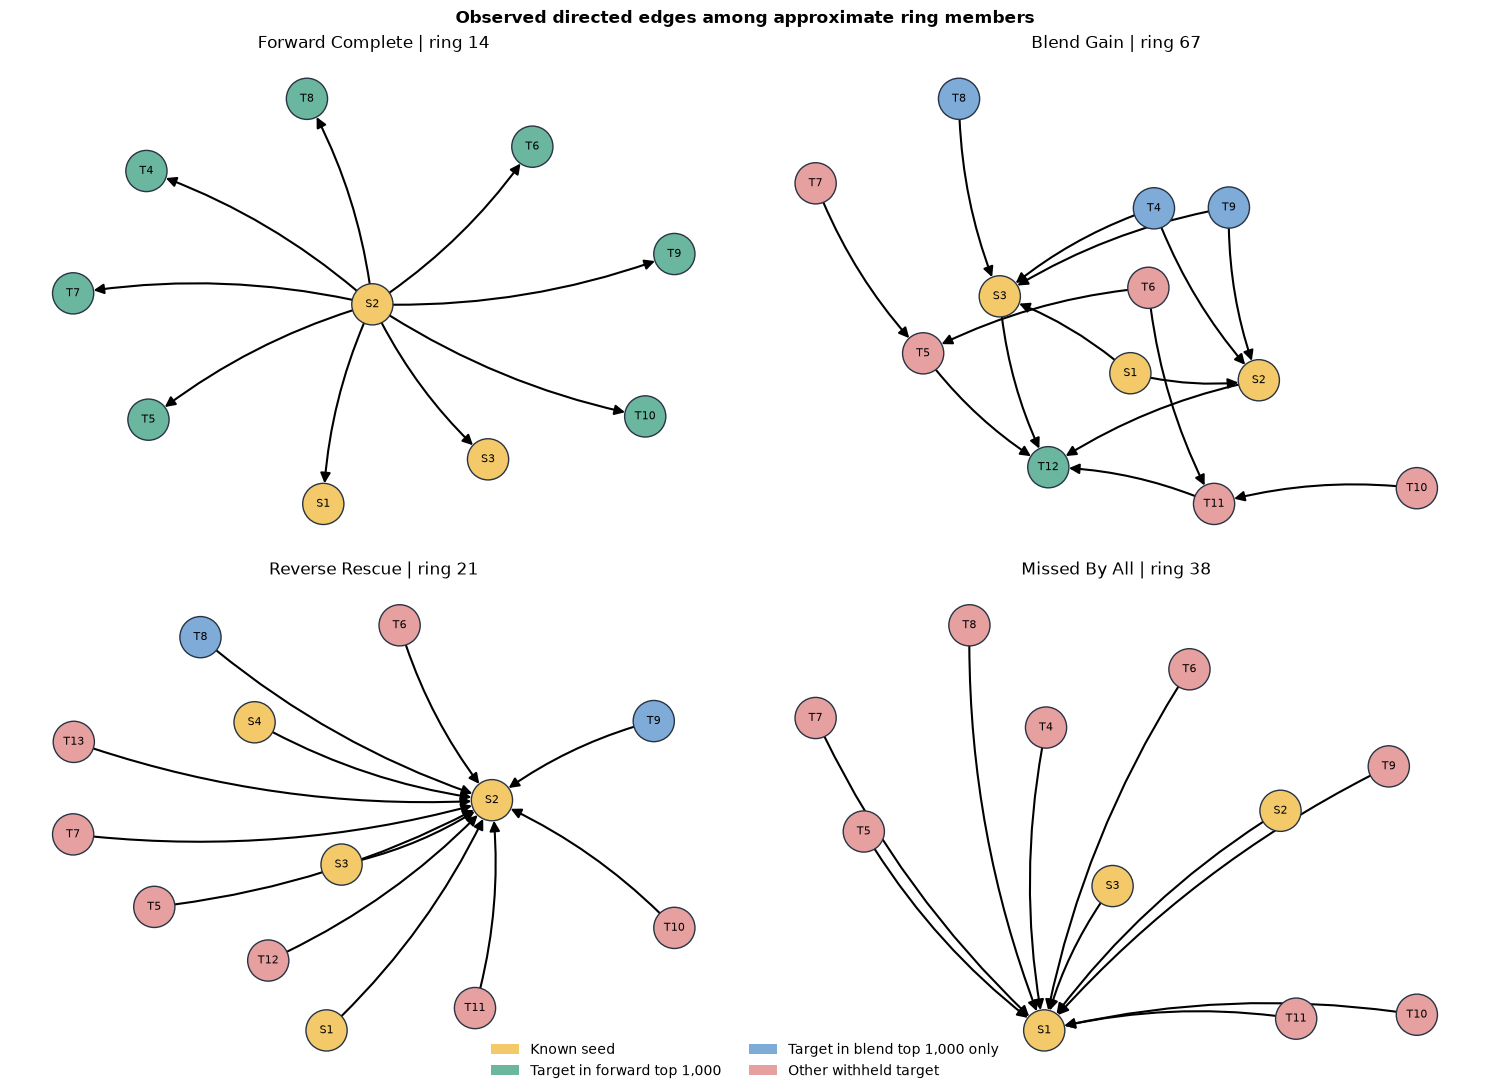

In [9]:
### draw observed transactions between each case's ring members
fig, axes = plt.subplots(
    nrows = 2,
    ncols = 2,
    figsize = (15, 11),
    squeeze = False
)
flat_axes = axes.ravel()

for ax, case in zip(flat_axes, representative_cases.iter_rows(named = True)):
    # representative ring id
    ring_id = int(
        case['ring_id']
    )

    # ring members
    members = case_analyzer.get_ring_nodes(
        ring_id = ring_id
    )

    # ring edges
    edges = case_analyzer.get_ring_edges(
        ring_id = ring_id
    )

    # graph view
    graph_view = nx.DiGraph()

    for row in members.iter_rows(named = True):
        graph_view.add_node(
            node_for_adding = int(
                row['node_id']
            )
        )

    for row in edges.iter_rows(named = True):
        graph_view.add_edge(
            u_of_edge = int(
                row['source_node_id']
            ),
            v_of_edge = int(
                row['target_node_id']
            ),
            weight = float(
                row['count_weight']
            )
        )

    # layout
    layout = nx.spring_layout(
        G = graph_view,
        seed = 2
    )

    # ring members by id
    members_by_id = {
        int(row['node_id']): row
        for row in members.iter_rows(named = True)
    }

    # labels
    labels = {
        node_id: (
            f"S{row['ring_member_order']}" if row['is_ring_seed']
            else f"T{row['ring_member_order']}"
        )
        for node_id, row in members_by_id.items()
    }

    # graph coloring
    colors = []
    for node_id in graph_view.nodes:
        row = members_by_id[node_id]

        if row['is_ring_seed']:
            colors.append('#f3c969')
        elif row['forward_rank'] <= case_analyzer.k:
            colors.append('#6bb69f')
        elif row['bidirectional_rank'] <= case_analyzer.k:
            colors.append('#7eabd8')
        else:
            colors.append('#e7a0a0')

    # draw graph nodes
    nx.draw_networkx_nodes(
        G = graph_view,
        pos = layout,
        ax = ax,
        node_color = colors,
        node_size = 880,
        edgecolors = '#283443',
        linewidths = 1
    )

    # draw graph labels
    nx.draw_networkx_labels(
        G = graph_view,
        pos = layout,
        labels = labels,
        ax = ax,
        font_size = 8
    )

    # draw graph edges
    nx.draw_networkx_edges(
        G = graph_view,
        pos = layout,
        ax = ax,
        arrows = True,
        arrowstyle = '-|>',
        arrowsize = 15,
        node_size = 880,
        width = 1.5,
        connectionstyle = 'arc3,rad=0.10'
    )

    ax.set_title(
        f"{case['case_type'].replace('_', ' ').title()} | ring {ring_id}"
    )

    ax.axis('off')

for ax in flat_axes[len(representative_cases):]:
    ax.axis('off')

fig.legend(
    handles = [
        Patch(
            facecolor = '#f3c969',
            label = 'Known seed'
        ),
        Patch(
            facecolor = '#6bb69f',
            label = 'Target in forward top 1,000'
        ),
        Patch(
            facecolor = '#7eabd8',
            label = 'Target in blend top 1,000 only'
        ),
        Patch(
            facecolor = '#e7a0a0',
            label = 'Other withheld target'
        )
    ],
    loc = 'lower center',
    ncol = 2,
    frameon = False
)

fig.suptitle(
    'Observed directed edges among approximate ring members',
    fontweight = 'bold'
)

plt.tight_layout()
plt.show()

**Node, edge, and network-view interpretation**

Arrows show observed fund-flow direction between ring members; labels distinguish known seeds (denoted by **S**) from withheld targets (denoted by **T**). Edges may repeat as transactions and are aggregated in the graph

The drawings make the direction effect visible:
- **Ring 14 is a forward fan-out**. Seed `S2` points directly to every other displayed member, and every target is recovered by forward PPR. Its observed out-degree is 12, so the direct ring edges still receive enough propagated mass to rank all 7 targets in the first 1,000
- **Ring 21 is a reverse-oriented fan-in**. Every withheld target points toward seed `S2`. Forward PPR cannot travel from that seed to the targets along the recorded arrows, whereas reverse PPR can. Only 2 of the 6 reverse hits survive the equal-weight blend 
- **Ring 38 is another fan-in, but its sink seed `S1` has in-degree 37 in the full observation graph**. Reverse propagation from that seed is therefore divided among many predecessors, which is consistent with even the best ring targets landing just outside the budget at ranks 1,009 and 1,021
- **Ring 67 has mixed directions and short chains.** One target is supported forward and three are supported in reverse, so this topology benefits from combining directions

All displayed within-ring `count_weight` values are 1.0 for these four cases; their different outcomes are therefore driven mainly by direction, surrounding graph degree, and global competition rather than repeated transactions on the displayed account pairs. The node degrees and event counts refer to the **full observation graph**, while the edge table and drawing show only transactions between selected ring members. This is why an account can have much higher activity than the small case diagram suggests

Coloring emphasizes forward and blended recovery. A red target can still be a **reverse-only** hit—as occurs in ring 21—so red should be read as “outside the forward and blended top 1,000,” not necessarily outside every ranking

In [10]:
### inspect the first non-target candidates in the forward ranking
with pl.Config(
    tbl_cols = -1,
    tbl_rows = -1
):
    display(
        case_analyzer.get_top_non_targets(
            top_n = 10
        )
    )

global_rank,node_id,account,personalized_pagerank_unweighted,in_degree,out_degree,account_transaction_event_count
u32,u64,str,f64,u64,u64,u64
1,402277,"""5632446313""",0.005532,1,1,4
2,707181,"""9153128438""",0.001876,1,1,2
3,359033,"""5132786366""",0.001595,1,0,1
4,598489,"""7901404180""",0.001418,1,1,2
5,575616,"""7635866133""",0.001418,1,1,4
6,242546,"""3790041873""",0.001291,1,1,2
7,334397,"""4848609813""",0.001291,1,0,7
8,757561,"""9735591723""",0.001291,1,1,4
9,676521,"""8799791564""",0.00127,1,0,1


**Review-queue interpretation**

**The first ten forward-ranked accounts outside the defined withheld-target set** are strikingly low-degree: each has at most one observed incoming and one outgoing neighbor, and their transaction-event counts range from **1 to 7**. The highest-ranked account has score **0.005532**, degree 1-in/1-out, and only four events

This confirms that personalized PageRank is not simply returning high-activity hubs. A low-degree account can rank highly when it lies very close to a seed and receives concentrated probability mass. Conversely, a highly active account can have a poor score if its direction and neighborhood do not support propagation from the chosen seeds

“Non-target” is only an experimental label: these accounts may be normal neighbors, suspicious accounts outside the reconstructed validation rings, or accounts not covered by the target definition. The table therefore describes the analyst-review workload, not ten proven false positives. Their seed paths, transactions, and local neighborhoods would need investigation before assigning a disposition

**Conclusion**

The case analysis explains the aggregate ranking behavior with transaction direction and global score competition:

1. Forward PPR is the strongest primary ranking at the chosen budget: it recovers **36.4% of targets**, versus **23.2%** for the equal-weight blend.
2. Reverse PPR remains a useful complementary view for fan-in structures. Ring 21 would be completely invisible to the forward queue but yields six reverse hits.
3. A simple score average is not uniformly beneficial. It combines complementary evidence in ring 67, but discards three forward hits in ring 14 and four reverse hits in ring 21.
4. A missed ring is not necessarily disconnected. Ring 38 has direct reverse paths for every target; two targets miss the reverse cutoff by only 9 and 21 positions.
5. Paths explain reachability, not causality or attribution. Exact ring-level contribution would require rerunning PPR with only the selected ring's seeds, and prospective performance still requires a strictly later test window.

The practical implication is to retain **forward PPR as the main review ranking** and expose **reverse PPR as a complementary queue or feature** rather than replacing both with the current equal-weight blend. A later experiment can compare rank fusion or tuned blend weights under the same fixed review budget. Therefore, exact **PPR score attribution to a particular ring** would require one additional PageRank computation with only that ring's seeds for each chosen case